In [1]:
import os
files = os.listdir("/kaggle/working/heatmaps")
print(f"Heatmaps available: {len(files)}")
# Should print 1373

Heatmaps available: 1373


In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║      U-Net Notebook — Tumour Segmentation                ║
# ╚══════════════════════════════════════════════════════════╝
# NOTE: Run VAE notebook first — it saves heatmaps to /kaggle/working/heatmaps/

!pip install -q torch torchvision matplotlib scikit-learn tqdm

import os, random, csv, numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [3]:

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT_ABNORMAL = "/kaggle/input/datasets/yatishrajan/lggdata/LGG/test/ABNORMAL"
MASK_ROOT_GLOBAL   = "/kaggle/input/datasets/yatishrajan/lggdata/LGG/masks"
HEATMAP_DIR        = "/kaggle/working/heatmaps"   # produced by VAE notebook
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, heatmap_dir, mode="baseline"):
        self.mode = mode
        self.samples = []
        
        # 1. Get all images from the abnormal directory
        if not os.path.exists(img_dir):
            print(f"Directory not found: {img_dir}")
            return
            
        imgs = sorted([f for f in os.listdir(img_dir) if f.endswith(".tif")])
        
        for img_f in imgs:
            # Match Mask Name: TCGA_XX_123.tif -> TCGA_XX_123_mask.tif
            mask_name = img_f.replace(".tif", "_mask.tif")
            mask_path = os.path.join(mask_dir, mask_name)
            
            # Match Heatmap Name: TCGA_XX_123.tif -> TCGA_XX_123_heatmap.npy
            heat_name = img_f.replace(".tif", "_heatmap.npy")
            heat_path = os.path.join(heatmap_dir, heat_name)
            
            # Only add to dataset if the image, mask, AND heatmap exist
            if os.path.exists(mask_path) and os.path.exists(heat_path):
                self.samples.append((
                    os.path.join(img_dir, img_f),
                    mask_path,
                    heat_path
                ))

    def __len__(self): 
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, heat_path = self.samples[idx]
        
        # Load and resize to model input size
        img = np.array(Image.open(img_path).convert("L").resize((256, 256))) / 255.0
        mask = np.array(Image.open(mask_path).convert("L").resize((256, 256))) / 255.0
        mask = (mask > 0.5).astype(np.float32)

        # Convert to tensors
        img_t  = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # [1, 256, 256]
        mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0) # [1, 256, 256]

        if self.mode == "heatmap":
            # Load VAE anomaly heatmap
            heat = np.load(heat_path)
            # Min-Max Normalize the heatmap
            heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
            # Resize to match image
            heat_r = np.array(Image.fromarray(heat).resize((256, 256), resample=Image.BILINEAR))
            heat_t = torch.tensor(heat_r, dtype=torch.float32).unsqueeze(0)
            
            # Concatenate to create a 2-channel input [Img, Heatmap]
            inp = torch.cat([img_t, heat_t], dim=0)
        else:
            # Standard 1-channel input [Img]
            inp = img_t

        return inp, mask_t

In [4]:
# ── 80/20 Train / Validation Split ───────────────────────────────────────────

def make_loaders(mode):
    ds = SegDataset(DATA_ROOT_ABNORMAL, MASK_ROOT_GLOBAL, HEATMAP_DIR, mode=mode)
    
    if len(ds) == 0:
        print(f" Warning: Dataset for mode '{mode}' is empty! Check paths.")
        return None, None

    n_train = int(0.8 * len(ds))
    n_val = len(ds) - n_train
    
    # Split using fixed seed for reproducibility
    train_ds, val_ds = random_split(
        ds, [n_train, n_val], 
        generator=torch.Generator().manual_seed(42)
    )
    
    return (DataLoader(train_ds, batch_size=8, shuffle=True),
            DataLoader(val_ds, batch_size=8, shuffle=False))

# --- Execution ---
base_train, base_val = make_loaders("baseline")
heat_train, heat_val = make_loaders("heatmap")

if base_train:
    print(f"✅ Baseline Dataset Found: {len(base_train.dataset)} samples")
    print(f"✅ Heatmap Dataset Found:  {len(heat_train.dataset)} samples")

✅ Baseline Dataset Found: 1098 samples
✅ Heatmap Dataset Found:  1098 samples


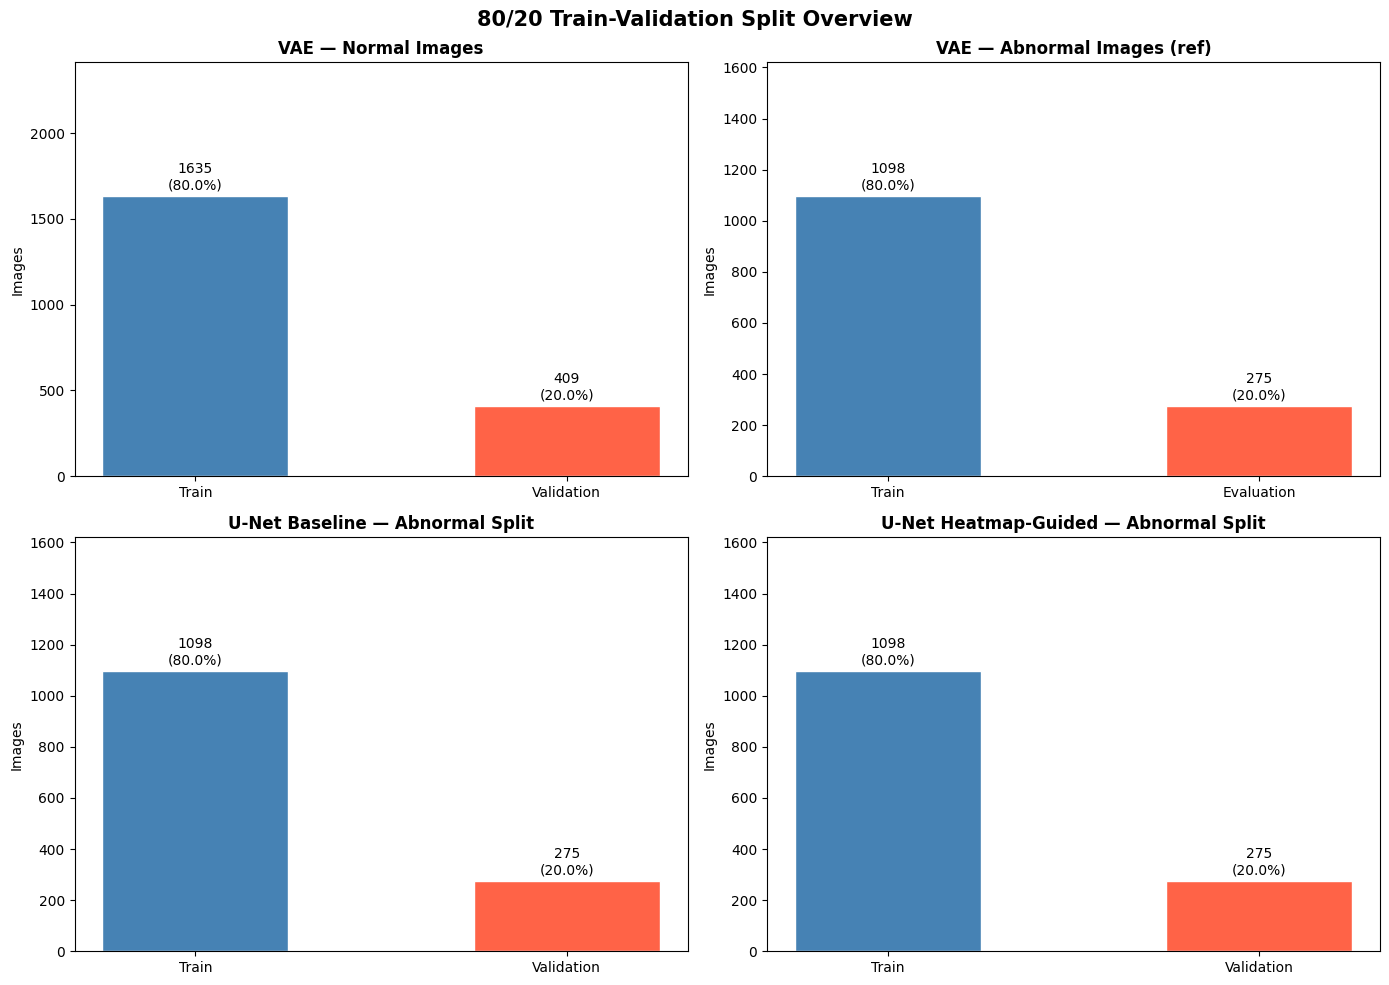

✅ Saved dataset_split_overview.png


In [5]:
# ── 80/20 Split Graphs — VAE (Normal + Abnormal) & U-Net (Baseline + Heatmap) ─
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("80/20 Train-Validation Split Overview", fontsize=15, fontweight="bold")
C = {"train":"steelblue","val":"tomato"}

# Counts
n_normal   = 2044   # update if different
n_abnormal = 1373
pairs = [
    (axes[0,0], "VAE — Normal Images",            n_normal,   ["Train","Validation"]),
    (axes[0,1], "VAE — Abnormal Images (ref)",     n_abnormal, ["Train","Evaluation"]),
    (axes[1,0], "U-Net Baseline — Abnormal Split",
        len(base_train.dataset)+len(base_val.dataset) if base_train else 0,
        ["Train","Validation"]),
    (axes[1,1], "U-Net Heatmap-Guided — Abnormal Split",
        len(heat_train.dataset)+len(heat_val.dataset) if heat_train else 0,
        ["Train","Validation"]),
]
for ax, title, total, xlabels in pairs:
    if total == 0:
        ax.text(0.5,0.5,"Not available",ha="center",va="center",transform=ax.transAxes); continue
    n_tr = int(0.8*total); n_vl = total - n_tr
    bars = ax.bar(xlabels, [n_tr, n_vl], color=[C["train"],C["val"]], width=0.5, edgecolor="white")
    ax.set_title(title, fontweight="bold"); ax.set_ylabel("Images")
    ax.set_ylim(0, total*1.18)
    for bar, val in zip(bars,[n_tr,n_vl]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+total*0.01,
                f"{val}\n({val/total*100:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("/kaggle/working/dataset_split_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved dataset_split_overview.png")


In [6]:
# ── U-Net Architecture ────────────────────────────────────────────────────────
def double_conv(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)
    )

class UNet(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.enc1 = double_conv(in_channels, 64)
        self.enc2 = double_conv(64, 128)
        self.enc3 = double_conv(128, 256)
        self.enc4 = double_conv(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = double_conv(512, 1024)
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = double_conv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = double_conv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = double_conv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = double_conv(128, 64)
        self.out  = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d  = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d  = self.dec3(torch.cat([self.up3(d), e3], dim=1))
        d  = self.dec2(torch.cat([self.up2(d), e2], dim=1))
        d  = self.dec1(torch.cat([self.up1(d), e1], dim=1))
        return torch.sigmoid(self.out(d))

unet_base = UNet(in_channels=1).to(DEVICE)
unet_heat = UNet(in_channels=2).to(DEVICE)
print("UNet baseline params:", sum(p.numel() for p in unet_base.parameters()))
print("Heatmap  params:", sum(p.numel() for p in unet_heat.parameters()))


UNet baseline params: 31042369
Heatmap  params: 31042945


In [7]:
# ── Loss & Metric Functions ───────────────────────────────────────────────────
def dice_loss(pred, target, smooth=1.0):
    p = pred.contiguous().view(-1)
    t = target.contiguous().view(-1)
    inter = (p * t).sum()
    return 1 - (2 * inter + smooth) / (p.sum() + t.sum() + smooth)

def combined_loss(pred, target, bce_w=0.5, dice_w=0.5):
    bce  = nn.functional.binary_cross_entropy(pred, target)
    dice = dice_loss(pred, target)
    return bce_w * bce + dice_w * dice, bce, dice

def dice_score(pred, target, threshold=0.5, smooth=1.0):
    p = (pred > threshold).float().contiguous().view(-1)
    t = target.contiguous().view(-1)
    inter = (p * t).sum()
    return (2 * inter + smooth) / (p.sum() + t.sum() + smooth)

def iou_score(pred, target, threshold=0.5, smooth=1.0):
    p = (pred > threshold).float().contiguous().view(-1)
    t = target.contiguous().view(-1)
    inter = (p * t).sum()
    union = p.sum() + t.sum() - inter
    return (inter + smooth) / (union + smooth)


In [8]:
# ── Training — Approach 1 (Baseline) & Approach 2 (Heatmap-guided) ───────────
EPOCHS_SEG = 30

def train_unet(model, train_loader, val_loader, tag=""):
    opt = optim.Adam(model.parameters(), lr=1e-4)
    hist = {"train_loss": [], "val_dice": [], "val_iou": []}

    for epoch in range(1, EPOCHS_SEG + 1):
        model.train(); ep_loss = 0.0
        for inp, mask in tqdm(train_loader, desc=f"[{tag}] Epoch {epoch}/{EPOCHS_SEG}", leave=False):
            inp, mask = inp.to(DEVICE), mask.to(DEVICE)
            opt.zero_grad()
            pred       = model(inp)
            loss, _, _ = combined_loss(pred, mask)
            loss.backward(); opt.step()
            ep_loss += loss.item()

        # Validation
        model.eval(); val_dice = val_iou = 0.0
        with torch.no_grad():
            for inp, mask in val_loader:
                inp, mask = inp.to(DEVICE), mask.to(DEVICE)
                pred = model(inp)
                val_dice += dice_score(pred, mask).item()
                val_iou  += iou_score(pred, mask).item()

        hist["train_loss"].append(ep_loss / len(train_loader))
        hist["val_dice"].append(val_dice / len(val_loader))
        hist["val_iou"].append(val_iou  / len(val_loader))
        if epoch % 5 == 0:
            print(f"[{tag}] Epoch {epoch}  Loss: {ep_loss/len(train_loader):.4f}"
                  f"  Dice: {val_dice/len(val_loader):.4f}"
                  f"  IoU:  {val_iou/len(val_loader):.4f}")
    return hist

hist_base = train_unet(unet_base, base_train, base_val, tag="Baseline")
hist_heat = train_unet(unet_heat, heat_train, heat_val, tag="Heatmap")

torch.save(unet_base.state_dict(), "/kaggle/working/unet_baseline.pth")
torch.save(unet_heat.state_dict(), "/kaggle/working/unet_heatmap.pth")
print("✅ Model weights saved")


[Baseline] Epoch 5  Loss: 0.4278  Dice: 0.7092  IoU:  0.5551


[Baseline] Epoch 10  Loss: 0.2153  Dice: 0.8203  IoU:  0.6986


[Baseline] Epoch 15  Loss: 0.1208  Dice: 0.8393  IoU:  0.7273


[Baseline] Epoch 20  Loss: 0.0804  Dice: 0.8645  IoU:  0.7639


[Baseline] Epoch 25  Loss: 0.0642  Dice: 0.8715  IoU:  0.7746


...

[Heatmap] Epoch 10  Loss: 0.1623  Dice: 0.8042  IoU:  0.6773


[Heatmap] Epoch 15  Loss: 0.1025  Dice: 0.8451  IoU:  0.7348


[Heatmap] Epoch 20  Loss: 0.0838  Dice: 0.8460  IoU:  0.7363


[Heatmap] Epoch 25  Loss: 0.0719  Dice: 0.8535  IoU:  0.7470


[Heatmap] Epoch 30  Loss: 0.0595  Dice: 0.8494  IoU:  0.7417
✅ Model weights saved


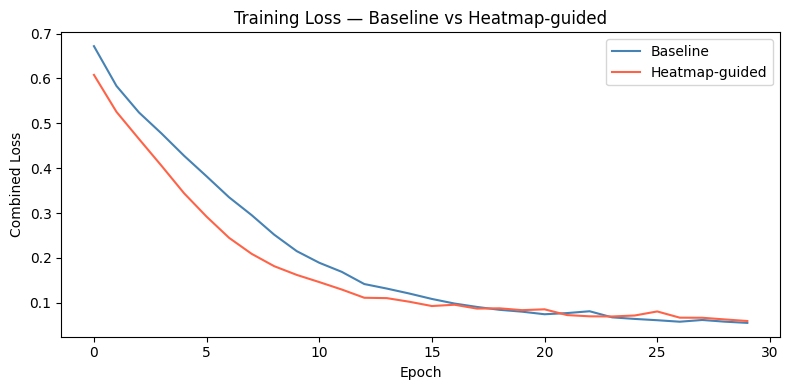

✅ Saved seg_training_loss.png


In [9]:
# ── Validation — Training Loss Curve ────────────────────────────────────────
plt.figure(figsize=(8,4))
plt.plot(hist_base["train_loss"], label="Baseline",       color="steelblue")
plt.plot(hist_heat["train_loss"], label="Heatmap-guided", color="tomato")
plt.xlabel("Epoch"); plt.ylabel("Combined Loss")
plt.title("Training Loss — Baseline vs Heatmap-guided"); plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/seg_training_loss.png", dpi=150)
plt.show()
print("✅ Saved seg_training_loss.png")


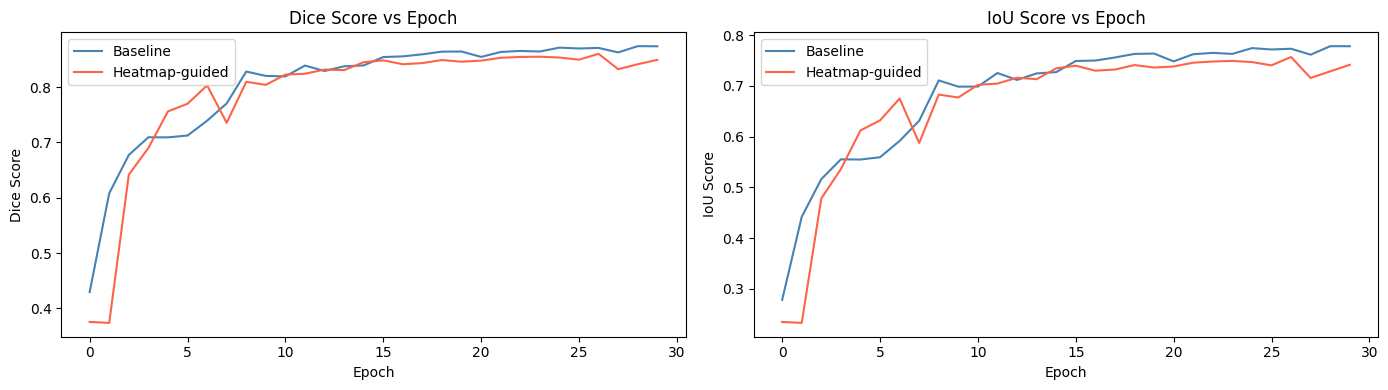

✅ Saved dice_iou_curves.png


In [10]:
# ── Validation — Dice & IoU Curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_base["val_dice"], label="Baseline",       color="steelblue")
axes[0].plot(hist_heat["val_dice"], label="Heatmap-guided", color="tomato")
axes[0].set_title("Dice Score vs Epoch"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Dice Score"); axes[0].legend()

axes[1].plot(hist_base["val_iou"], label="Baseline",       color="steelblue")
axes[1].plot(hist_heat["val_iou"], label="Heatmap-guided", color="tomato")
axes[1].set_title("IoU Score vs Epoch"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU Score"); axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/dice_iou_curves.png", dpi=150)
plt.show()
print("✅ Saved dice_iou_curves.png")


In [11]:
# ── Evaluation — Overall Dice & IoU ──────────────────────────────────────────
def eval_model(model, loader):
    model.eval(); all_dice, all_iou = [], []
    with torch.no_grad():
        for inp, mask in loader:
            inp,mask=inp.to(DEVICE),mask.to(DEVICE)
            pred=model(inp)
            for i in range(pred.shape[0]):
                all_dice.append(dice_score(pred[i:i+1],mask[i:i+1]).item())
                all_iou.append( iou_score( pred[i:i+1],mask[i:i+1]).item())
    return np.mean(all_dice),np.std(all_dice),np.mean(all_iou),np.std(all_iou)

d_b,d_b_std,i_b,i_b_std = eval_model(unet_base, base_val)
d_h,d_h_std,i_h,i_h_std = eval_model(unet_heat, heat_val)

print("="*52)
print(f"{'Metric':<18} {'Baseline':>14} {'Heatmap-guided':>16}")
print("-"*52)
print(f"{'Dice Score':<18} {d_b:.4f}±{d_b_std:.4f}  {d_h:.4f}±{d_h_std:.4f}")
print(f"{'IoU Score':<18} {i_b:.4f}±{i_b_std:.4f}  {i_h:.4f}±{i_h_std:.4f}")
print("="*52)


Metric                   Baseline   Heatmap-guided
----------------------------------------------------
Dice Score         0.7932±0.2265  0.7602±0.2468
IoU Score          0.7024±0.2423  0.6642±0.2585


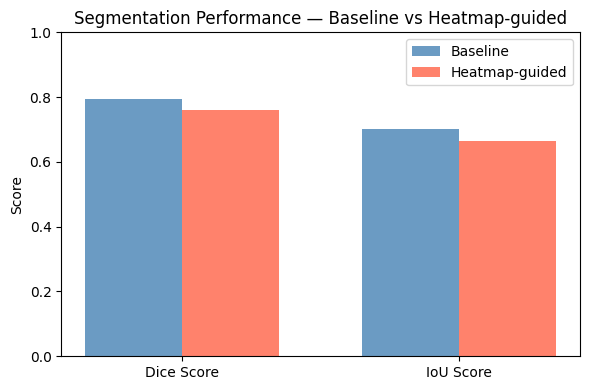

✅ Saved comparison_bar.png


In [12]:
# ── Evaluation — Comparison Bar Chart ────────────────────────────────────────
labels_bar  = ["Dice Score", "IoU Score"]
base_scores = [d_b, i_b]
heat_scores = [d_h, i_h]
x = np.arange(len(labels_bar)); w = 0.35

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x-w/2, base_scores, w, label="Baseline",       color="steelblue", alpha=0.8)
ax.bar(x+w/2, heat_scores, w, label="Heatmap-guided", color="tomato",    alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels_bar)
ax.set_ylim(0,1); ax.set_ylabel("Score")
ax.set_title("Segmentation Performance — Baseline vs Heatmap-guided"); ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/comparison_bar.png", dpi=150)
plt.show()
print("✅ Saved comparison_bar.png")


In [13]:
# ── Evaluation — Save Per-Image Results with Dice & IoU Scores ───────────────
RESULTS_BASE_DIR = "/kaggle/working/results_baseline"
RESULTS_HEAT_DIR = "/kaggle/working/results_heatmap"
os.makedirs(RESULTS_BASE_DIR, exist_ok=True)
os.makedirs(RESULTS_HEAT_DIR, exist_ok=True)

def save_result_image(img_np, heat_np, mask_np, pred_np, d, iou, save_path, mode="baseline", title=""):
    if mode=="heatmap":
        fig, axes = plt.subplots(1,5,figsize=(20,4))
        col_titles = ["Input MRI","Heatmap Input","Ground Truth","Predicted Mask","Overlay"]
    else:
        fig, axes = plt.subplots(1,4,figsize=(16,4))
        col_titles = ["Input MRI","Ground Truth","Predicted Mask","Overlay"]
    heat_rgb = cm.jet(heat_np/(heat_np.max()+1e-8))[:,:,:3]
    overlay  = np.clip(0.6*np.stack([img_np]*3,-1)+0.4*heat_rgb,0,1)
    col=0
    axes[col].imshow(img_np,cmap="gray"); axes[col].set_title(col_titles[col]); axes[col].axis("off"); col+=1
    if mode=="heatmap":
        axes[col].imshow(heat_np,cmap="hot"); axes[col].set_title(col_titles[col]); axes[col].axis("off"); col+=1
    axes[col].imshow(mask_np,cmap="gray");       axes[col].set_title(col_titles[col]); axes[col].axis("off"); col+=1
    axes[col].imshow(pred_np>0.5,cmap="gray");   axes[col].set_title(col_titles[col]); axes[col].axis("off"); col+=1
    axes[col].imshow(overlay);                   axes[col].set_title(col_titles[col]); axes[col].axis("off")
    fig.suptitle(f"{title}  |  Dice={d:.4f}  IoU={iou:.4f}", fontsize=11, fontweight="bold")
    plt.tight_layout(); plt.savefig(save_path,dpi=100,bbox_inches="tight"); plt.close()

# --- Approach 1: Baseline ---
base_rows=[]
unet_base.eval()
with torch.no_grad():
    for inp_b, mask_b in base_val:
        preds = unet_base(inp_b.to(DEVICE)).cpu()
        for i in range(inp_b.shape[0]):
            d   = dice_score(preds[i:i+1], mask_b[i:i+1]).item()
            iou = iou_score( preds[i:i+1], mask_b[i:i+1]).item()
            idx = len(base_rows)
            fname = f"sample_{idx:04d}_baseline.png"
            save_result_image(inp_b[i,0].numpy(), np.zeros((256,256)),
                              mask_b[i,0].numpy(), preds[i,0].numpy(),
                              d, iou, os.path.join(RESULTS_BASE_DIR,fname),
                              mode="baseline", title=f"Baseline {idx:04d}")
            base_rows.append({"image":fname,"dice":f"{d:.6f}","iou":f"{iou:.6f}"})

with open(os.path.join(RESULTS_BASE_DIR,"baseline_scores.csv"),"w",newline="") as f:
    w=csv.DictWriter(f,fieldnames=["image","dice","iou"]); w.writeheader(); w.writerows(base_rows)
print(f"✅ Baseline results: {len(base_rows)} images → {RESULTS_BASE_DIR}")

# --- Approach 2: Heatmap-guided ---
heat_rows=[]
unet_heat.eval()
with torch.no_grad():
    for inp_h, mask_h in heat_val:
        preds = unet_heat(inp_h.to(DEVICE)).cpu()
        for i in range(inp_h.shape[0]):
            d   = dice_score(preds[i:i+1], mask_h[i:i+1]).item()
            iou = iou_score( preds[i:i+1], mask_h[i:i+1]).item()
            idx = len(heat_rows)
            fname = f"sample_{idx:04d}_heatmap.png"
            save_result_image(inp_h[i,0].numpy(), inp_h[i,1].numpy(),
                              mask_h[i,0].numpy(), preds[i,0].numpy(),
                              d, iou, os.path.join(RESULTS_HEAT_DIR,fname),
                              mode="heatmap", title=f"Heatmap {idx:04d}")
            heat_rows.append({"image":fname,"dice":f"{d:.6f}","iou":f"{iou:.6f}"})

with open(os.path.join(RESULTS_HEAT_DIR,"heatmap_scores.csv"),"w",newline="") as f:
    w=csv.DictWriter(f,fieldnames=["image","dice","iou"]); w.writeheader(); w.writerows(heat_rows)
print(f"✅ Heatmap results : {len(heat_rows)} images → {RESULTS_HEAT_DIR}")

dices_b=[float(r["dice"]) for r in base_rows]; ious_b=[float(r["iou"]) for r in base_rows]
dices_h=[float(r["dice"]) for r in heat_rows]; ious_h=[float(r["iou"]) for r in heat_rows]
print(f"\nBaseline  Dice:{np.mean(dices_b):.4f}±{np.std(dices_b):.4f}  IoU:{np.mean(ious_b):.4f}±{np.std(ious_b):.4f}")
print(f"Heatmap   Dice:{np.mean(dices_h):.4f}±{np.std(dices_h):.4f}  IoU:{np.mean(ious_h):.4f}±{np.std(ious_h):.4f}")


✅ Baseline results: 275 images → /kaggle/working/results_baseline
✅ Heatmap results : 275 images → /kaggle/working/results_heatmap

Baseline  Dice:0.7932±0.2265  IoU:0.7024±0.2423
Heatmap   Dice:0.7602±0.2468  IoU:0.6642±0.2585


In [14]:
# ── Download All U-Net Outputs ────────────────────────────────────────────────
import zipfile
from IPython.display import FileLink, display

UNET_ZIP = "/kaggle/working/unet_all_outputs.zip"
DIRS = {
    "results_baseline": "/kaggle/working/results_baseline",
    "results_heatmap":  "/kaggle/working/results_heatmap",
}
PLOTS = [
    "/kaggle/working/dataset_split_overview.png",
    "/kaggle/working/seg_training_loss.png",
    "/kaggle/working/dice_iou_curves.png",
    "/kaggle/working/comparison_bar.png",
    "/kaggle/working/unet_baseline.pth",
    "/kaggle/working/unet_heatmap.pth",
]

with zipfile.ZipFile(UNET_ZIP,"w",zipfile.ZIP_DEFLATED) as zf:
    for folder_name, folder_path in DIRS.items():
        if not os.path.exists(folder_path):
            print(f"⚠️  Skipping: {folder_path}"); continue
        for root,_,files in os.walk(folder_path):
            for f in files:
                abs_p=os.path.join(root,f)
                zf.write(abs_p, os.path.join(folder_name,os.path.relpath(abs_p,folder_path)))
        print(f"✅ Packed: {folder_name}/")
    for fp in PLOTS:
        if os.path.exists(fp):
            zf.write(fp, os.path.join("plots_and_weights",os.path.basename(fp)))
            print(f"✅ Packed: {os.path.basename(fp)}")

print(f"\n📦 ZIP size: {os.path.getsize(UNET_ZIP)/1024/1024:.1f} MB")
display(FileLink(UNET_ZIP, result_html_prefix="⬇️  Download U-Net outputs: "))


✅ Packed: results_baseline/
✅ Packed: results_heatmap/
✅ Packed: dataset_split_overview.png
✅ Packed: seg_training_loss.png
✅ Packed: dice_iou_curves.png
✅ Packed: comparison_bar.png
✅ Packed: unet_baseline.pth
✅ Packed: unet_heatmap.pth

📦 ZIP size: 350.6 MB


/kaggle/working/unet_all_outputs.zip